<a href="https://colab.research.google.com/github/shijithpulikkal/Exploratory-Data-Analysis/blob/main/05_amazon_reviews_text_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/My Drive/Colab Notebooks/EDA/Reviews.csv',
    encoding='latin1'
)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
df.shape

(568454, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [7]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [8]:
# Convert Unix timestamp to datetime
df['review_date'] = pd.to_datetime(df['Time'], unit='s')
df[['Time', 'review_date']].head()

,Time,review_date
0,1303862400,2011-04-27
1,1346976000,2012-09-07
2,1219017600,2008-08-18
3,1307923200,2011-06-13
4,1350777600,2012-10-21


**2. Data Cleaning**

In [9]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

,0
Summary,27
ProfileName,26
Id,0
UserId,0
ProductId,0
HelpfulnessDenominator,0
HelpfulnessNumerator,0
Score,0
Time,0
Text,0


In [10]:
# Drop rows with missing Text or Summary (small number, essential for text analysis)
df = df.dropna(subset=['Text', 'Summary'])
df.shape

(568427, 11)

In [11]:
# Check duplicates - same user/profile/text combo
print(df.duplicated(subset=['UserId', 'ProfileName', 'Text']).sum())
df = df.drop_duplicates(subset=['UserId', 'ProfileName', 'Text'])
df.shape

174783


(393644, 11)

In [12]:
# Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)          # remove HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)        # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra whitespace
    return text

df['clean_text'] = df['Text'].apply(clean_text)
df[['Text', 'clean_text']].head()

,Text,clean_text
0,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...
2,This is a confection that has been around a fe...,this is a confection that has been around a fe...
3,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...
4,Great taffy at a great price. There was a wid...,great taffy at a great price there was a wide ...


In [13]:
# Review length and summary length (word count)
df['review_length'] = df['clean_text'].apply(lambda x: len(x.split()))
df['summary_length'] = df['Summary'].astype(str).apply(lambda x: len(x.split()))

df[['review_length', 'summary_length']].describe()

,review_length,summary_length
count,393644.000000,393644.000000
mean,80.372392,4.087965
std,77.089007,2.583817
min,0.000000,1.000000
25%,34.000000,2.000000
50%,57.000000,3.000000
75%,98.000000,5.000000
max,3428.000000,42.000000


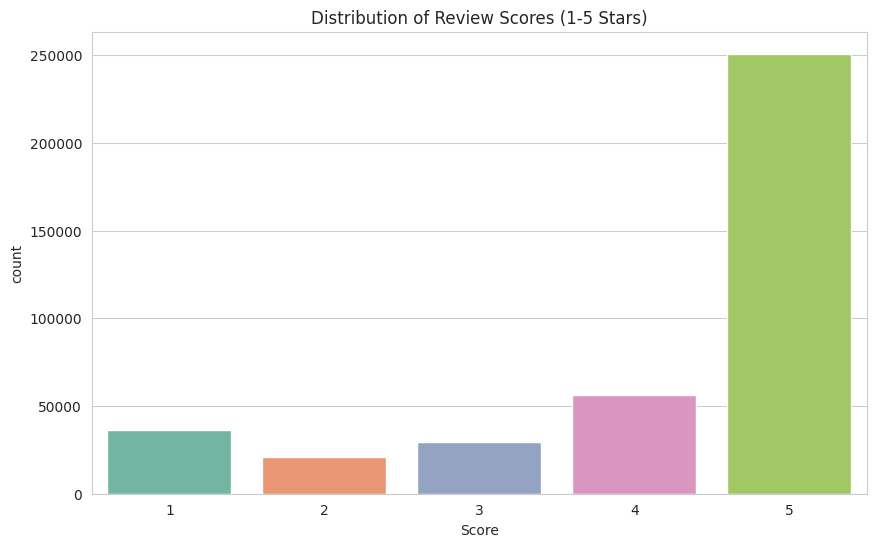

In [14]:
# Score distribution
sns.countplot(data=df, x='Score', hue='Score', palette='Set2', legend=False)
plt.title('Distribution of Review Scores (1-5 Stars)')
plt.show()

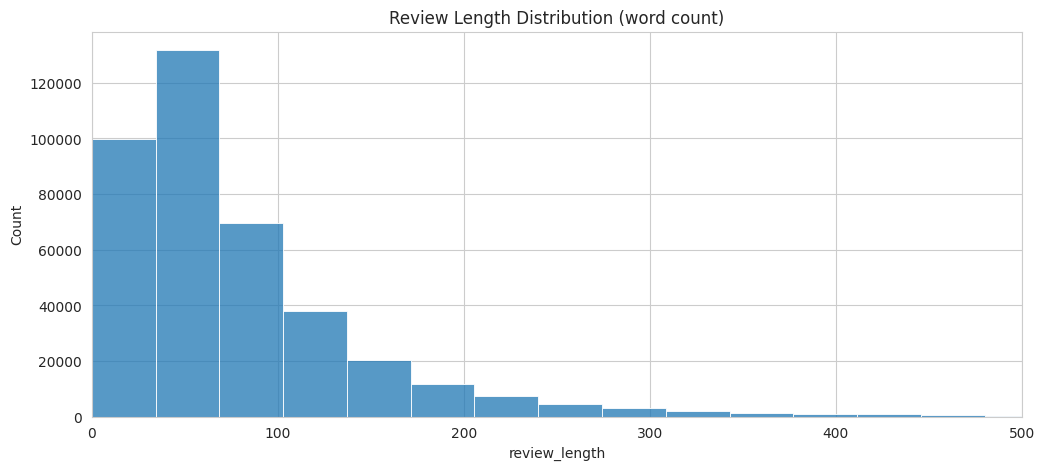

In [15]:
# Review length distribution
plt.figure(figsize=(12,5))
sns.histplot(df['review_length'], bins=100)
plt.title('Review Length Distribution (word count)')
plt.xlim(0, 500)  # most reviews are short; trims long tail for readability
plt.show()

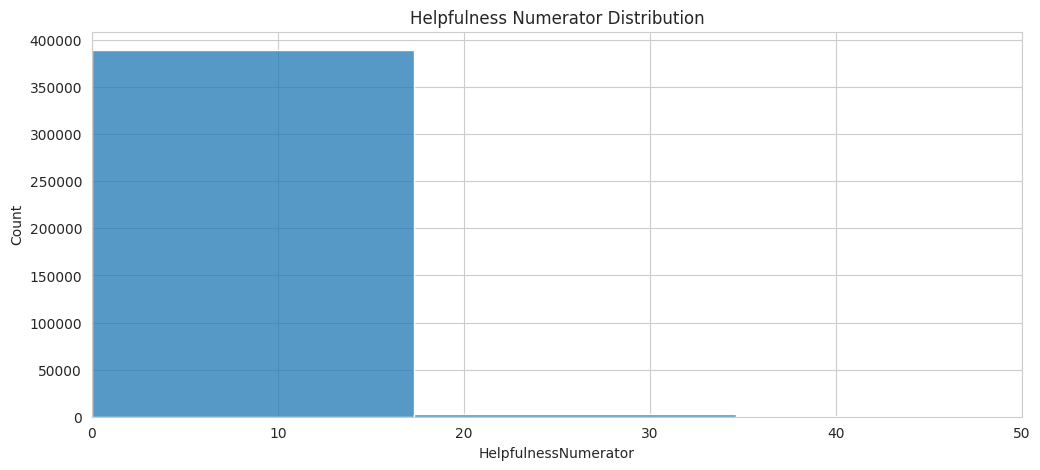

In [16]:
# Helpfulness columns
plt.figure(figsize=(12,5))
sns.histplot(df['HelpfulnessNumerator'], bins=50)
plt.title('Helpfulness Numerator Distribution')
plt.xlim(0, 50)
plt.show()

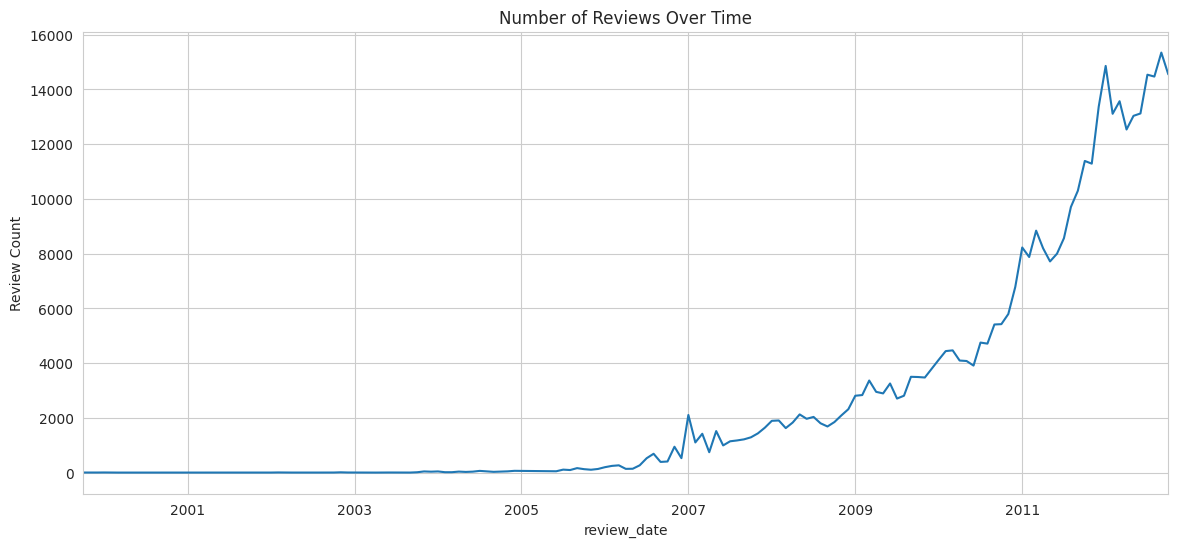

In [17]:
# Reviews over time - volume trend
reviews_over_time = df.set_index('review_date').resample('ME').size()

plt.figure(figsize=(14,6))
reviews_over_time.plot()
plt.title('Number of Reviews Over Time')
plt.ylabel('Review Count')
plt.show()

**4. Text Analysis**

In [18]:
!pip install nltk -q
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


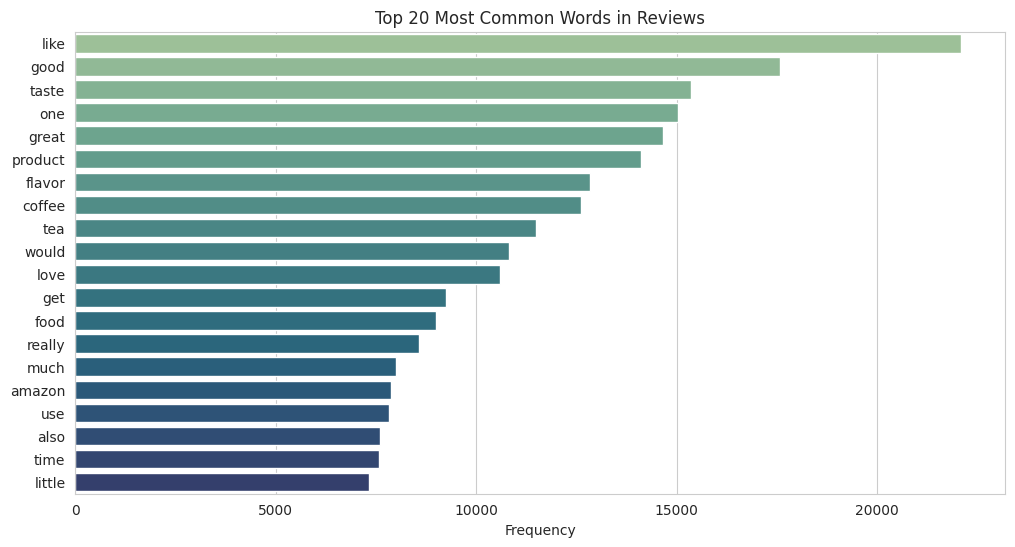

In [19]:
from collections import Counter

# Most common words overall (excluding stopwords)
all_words = ' '.join(df['clean_text'].sample(50000, random_state=42)).split()  # sample for speed
filtered_words = [w for w in all_words if w not in stop_words and len(w) > 2]

word_freq = Counter(filtered_words).most_common(20)
words, counts = zip(*word_freq)

plt.figure(figsize=(12,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='crest', legend=False)
plt.title('Top 20 Most Common Words in Reviews')
plt.xlabel('Frequency')
plt.show()

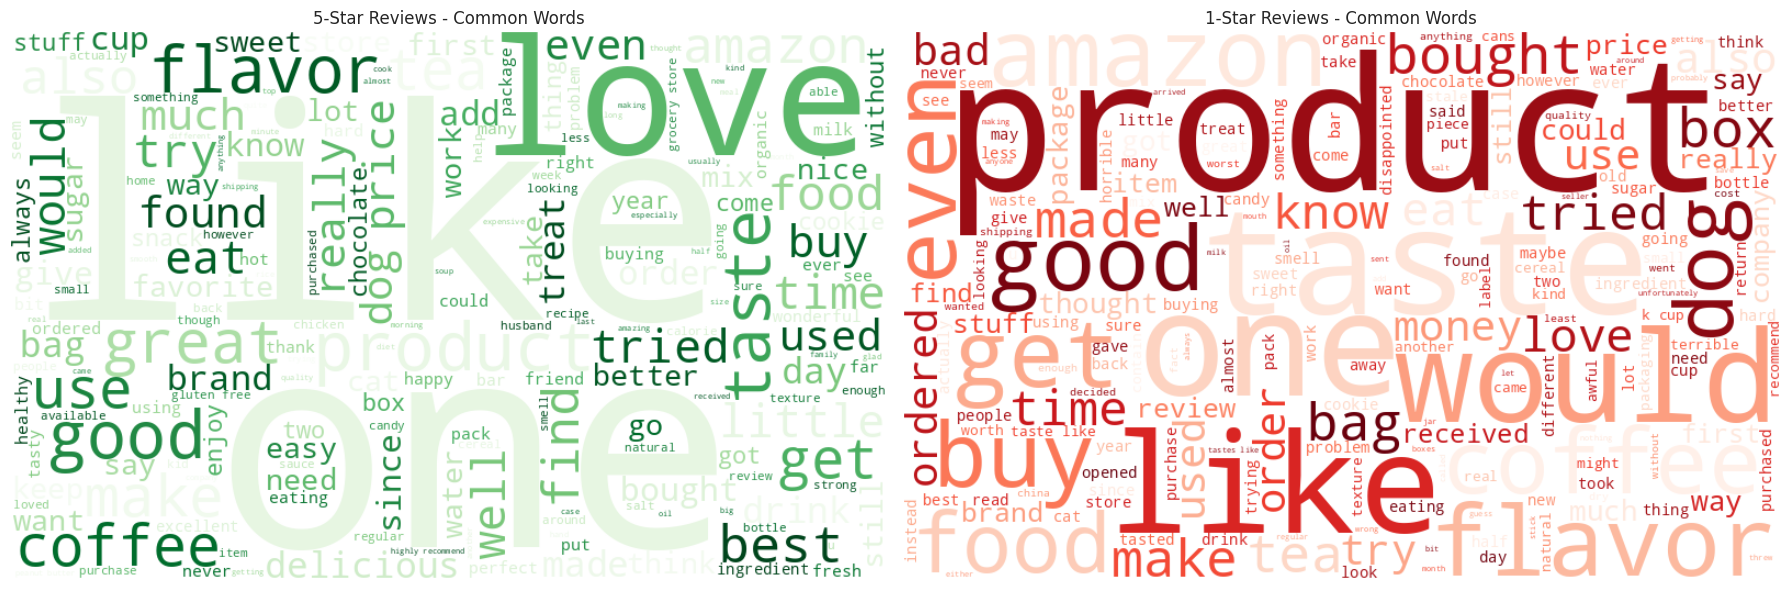

In [20]:
# Word clouds: 5-star vs 1-star reviews
!pip install wordcloud -q
from wordcloud import WordCloud

positive_text = ' '.join(df[df['Score'] == 5]['clean_text'].sample(10000, random_state=42))
negative_text = ' '.join(df[df['Score'] == 1]['clean_text'].sample(min(10000, (df['Score']==1).sum()), random_state=42))

wc_pos = WordCloud(width=800, height=500, background_color='white',
                     stopwords=stop_words, colormap='Greens').generate(positive_text)
wc_neg = WordCloud(width=800, height=500, background_color='white',
                     stopwords=stop_words, colormap='Reds').generate(negative_text)

fig, axes = plt.subplots(1, 2, figsize=(18,8))
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('5-Star Reviews - Common Words')
axes[0].axis('off')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('1-Star Reviews - Common Words')
axes[1].axis('off')

plt.tight_layout()
plt.show()

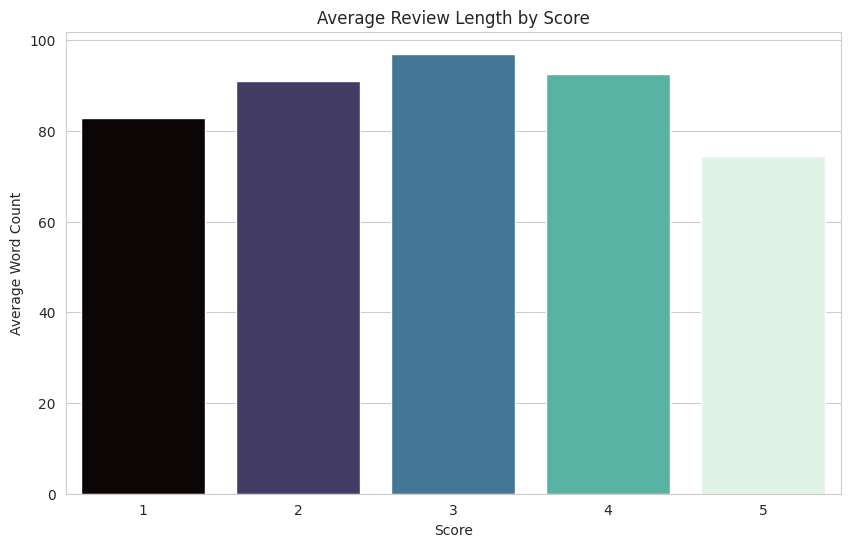

In [21]:
# Average review length by score
avg_len_by_score = df.groupby('Score')['review_length'].mean()

sns.barplot(x=avg_len_by_score.index, y=avg_len_by_score.values, hue=avg_len_by_score.index, palette='mako', legend=False)
plt.title('Average Review Length by Score')
plt.ylabel('Average Word Count')
plt.show()

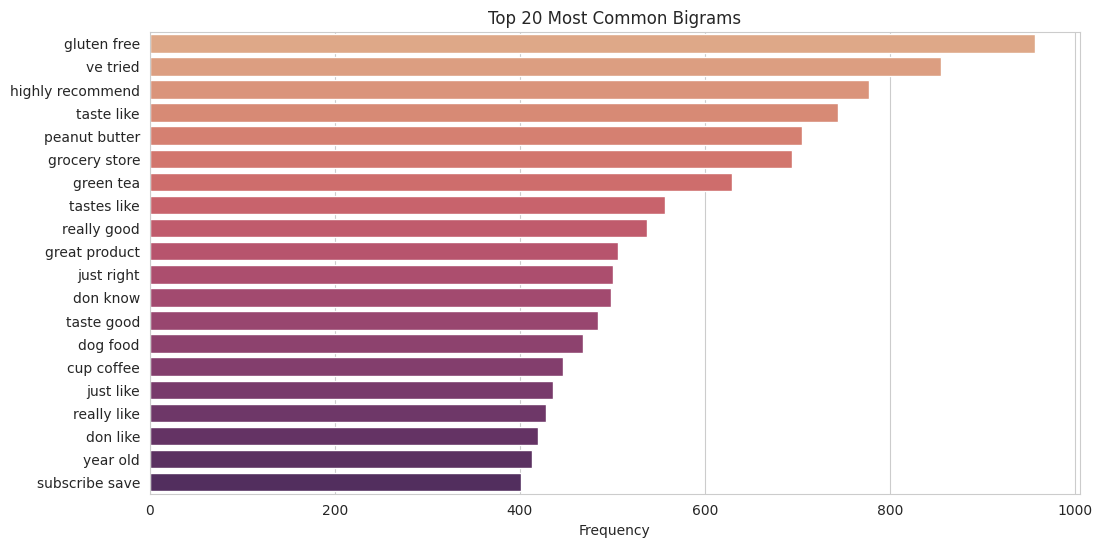

In [22]:
# Most common bigrams
from sklearn.feature_extraction.text import CountVectorizer

sample_text = df['clean_text'].sample(30000, random_state=42)

vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features=20)
bigram_matrix = vectorizer.fit_transform(sample_text)
bigram_counts = bigram_matrix.sum(axis=0)
bigram_freq = [(word, bigram_counts[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
bigram_freq = sorted(bigram_freq, key=lambda x: x[1], reverse=True)

bigrams, bcounts = zip(*bigram_freq)

plt.figure(figsize=(12,6))
sns.barplot(x=list(bcounts), y=list(bigrams), hue=list(bigrams), palette='flare', legend=False)
plt.title('Top 20 Most Common Bigrams')
plt.xlabel('Frequency')
plt.show()

**5. Bivariate / Multivariate Analysis**

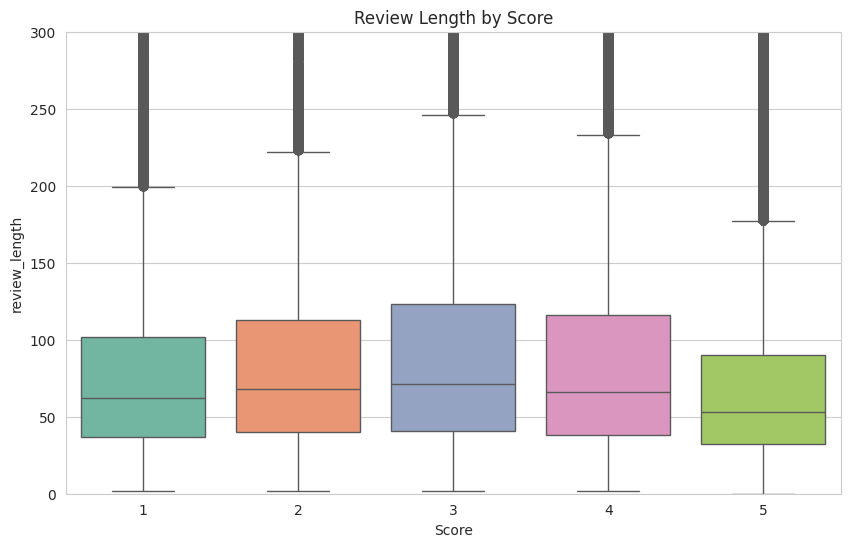

In [23]:
# Review length vs Score
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Score', y='review_length', hue='Score', palette='Set2', legend=False)
plt.ylim(0, 300)
plt.title('Review Length by Score')
plt.show()

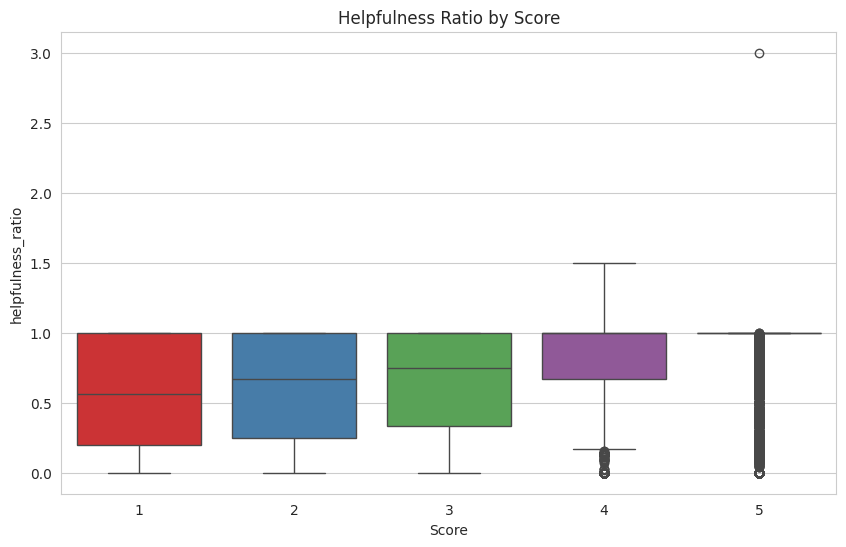

In [24]:
# Helpfulness ratio vs Score
df_helpful = df[df['HelpfulnessDenominator'] > 0].copy()
df_helpful['helpfulness_ratio'] = df_helpful['HelpfulnessNumerator'] / df_helpful['HelpfulnessDenominator']

plt.figure(figsize=(10,6))
sns.boxplot(data=df_helpful, x='Score', y='helpfulness_ratio', hue='Score', palette='Set1', legend=False)
plt.title('Helpfulness Ratio by Score')
plt.show()

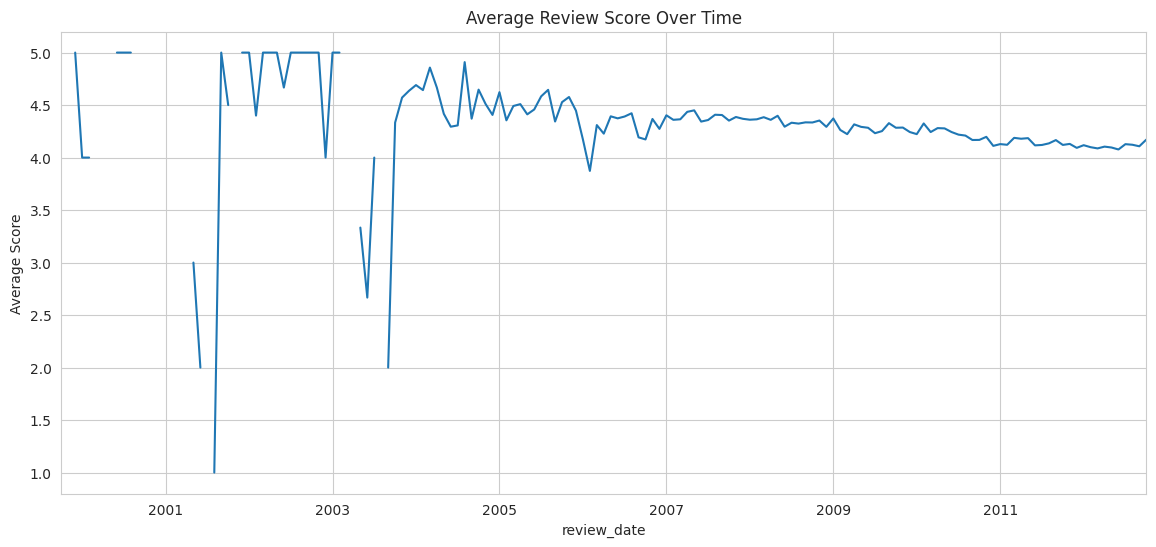

In [25]:
# Average score over time
avg_score_over_time = df.set_index('review_date').resample('ME')['Score'].mean()

plt.figure(figsize=(14,6))
avg_score_over_time.plot()
plt.title('Average Review Score Over Time')
plt.ylabel('Average Score')
plt.show()

**6. Insights Summary**

## Key Insights

- The dataset is heavily skewed toward 5-star reviews, indicating strong positive rating bias typical of e-commerce review platforms.
- Negative (1-star) reviews tend to be [longer/shorter] on average than positive reviews — describe based on your chart.
- Common words in positive reviews center around [taste/quality/love], while negative reviews frequently mention [words you observed like "refund", "stale", "disappointed"].
- Helpfulness ratio is [higher/similar] for extreme ratings (1 and 5 stars), suggesting readers find polarized opinions more useful than neutral ones.
- Review volume has grown significantly over time, tracking the platform's overall growth.
- Average score over time has remained [stable/shifted] — note direction if any drift is visible.
- [Add 1-2 more insights specific to what you observed]